In [ ]:
# Create workspace
!mkdir -p data
%cd data

# Download DIV2K training images (HR)
!wget http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip

# Unzip
!unzip DIV2K_train_HR.zip

# Rename for clarity
!mv DIV2K_train_HR clean_images


/content/data
--2025-12-28 18:28:10--  http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
Resolving data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)... 129.132.52.178, 2001:67c:10ec:36c2::178
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip [following]
--2025-12-28 18:28:11--  https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3530603713 (3.3G) [application/zip]
Saving to: ‘DIV2K_train_HR.zip.1’

DIV2K_train_HR.zip. 100%[===================>]   3.29G  22.1MB/s    in 2m 37s  

2025-12-28 18:30:48 (21.5 MB/s) - ‘DIV2K_train_HR.zip.1’ saved [3530603713/3530603713]

Archive:  DIV2K_train_HR.zip
   creating: DIV2K_train_HR/
  inflating: DIV2K_train_HR/0103.png  
 

In [ ]:
!cd -

/


# Imports

In [ ]:
import os
import math
import random
import numpy as np

import yaml
from tqdm import tqdm

import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import numbers
from einops import rearrange



## Example Image

(np.float64(-0.5), np.float64(2039.5), np.float64(1403.5), np.float64(-0.5))

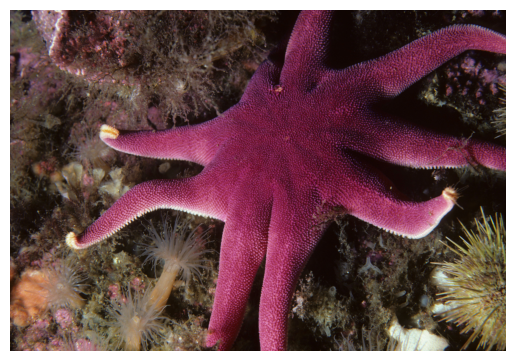

In [ ]:
img = Image.open("clean_images/0001.png")
plt.imshow(img)
plt.axis("off")


## Exposure Simulation
- Apply realistic exposure degradation using:
  - **Gain (α)** – controls exposure strength
  - **Gamma (γ)** – models camera response
  - **Bias (β)** – shifts global brightness
- Generate diverse over/under-exposed inputs via random sampling


In [ ]:
# -----------------------------
# Exposure model
# -----------------------------
def apply_exposure(img, alpha, gamma, beta):
    """
    img   : uint8 RGB [0,255]
    alpha : exposure gain
    gamma : camera response
    beta  : bias term
    """
    img = img.astype(np.float32) / 255.0
    img = np.power(alpha * img, gamma) + beta
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)


def generate_exposed_image(img):
    """
    Randomly sample realistic exposure params
    """
    alpha = random.uniform(1.3, 2.2)
    gamma = random.uniform(0.6, 0.9)
    beta  = random.uniform(0.05, 0.20)
    return apply_exposure(img, alpha, gamma, beta)

# -----------------------------
# Dataset creation
# -----------------------------
def create_split(clean_dir, file_list, split_name):
    input_dir = f"exposure_dataset/{split_name}/input"
    target_dir = f"exposure_dataset/{split_name}/target"

    os.makedirs(input_dir, exist_ok=True)
    os.makedirs(target_dir, exist_ok=True)

    for fname in tqdm(file_list, desc=f"Creating {split_name}"):
        img = cv2.imread(os.path.join(clean_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        exposed = generate_exposed_image(img)

        cv2.imwrite(
            os.path.join(input_dir, fname),
            cv2.cvtColor(exposed, cv2.COLOR_RGB2BGR)
        )
        cv2.imwrite(
            os.path.join(target_dir, fname),
            cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        )

##  Train / Validation / Test Split
- **700** images for training  
- **50** images for validation  
- **50** images for testing  
- Store paired data:
  - *Input*: exposed image  
  - *Target*: clean reference image

In [ ]:
CLEAN_DATASET = "clean_images"

files = sorted(os.listdir(CLEAN_DATASET))
assert len(files) == 800, "DIV2K train should have 800 images"

train_files = files[:700]
val_files   = files[700:750]
test_files  = files[750:800]

create_split(CLEAN_DATASET, train_files, "train")
create_split(CLEAN_DATASET, val_files, "val")
create_split(CLEAN_DATASET, test_files, "test")


(np.float64(-0.5), np.float64(2039.5), np.float64(1355.5), np.float64(-0.5))

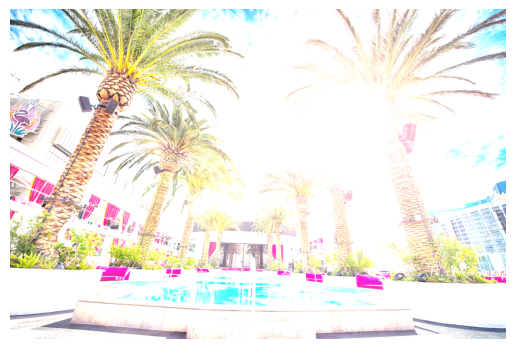

In [ ]:
img = Image.open("exposure_dataset/train/input/0003.png")
plt.imshow(img)
plt.axis("off")

## PyTorch Dataset
- Load paired input–target images
- Resize to fixed resolution
- Convert images to tensors
- Return filename for tracking and visualization

In [ ]:
class ExposureDataset(Dataset):
    """
    Paired dataset:
      input  = over/under-exposed image
      target = clean reference
    """

    def __init__(self, input_dir, target_dir, img_size=256):
        self.input_dir = input_dir
        self.target_dir = target_dir
        self.files = sorted(os.listdir(input_dir))

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        inp = Image.open(os.path.join(self.input_dir, self.files[idx])).convert("RGB")
        tgt = Image.open(os.path.join(self.target_dir, self.files[idx])).convert("RGB")

        return {
            "input": self.transform(inp),
            "target": self.transform(tgt),
            "name": self.files[idx]
        }

## Loss Functions
- **L1 / Exposure Loss**
  - Pixel-wise reconstruction loss
- **Charbonnier Loss**
  - Smooth, robust alternative to L1/L2
- **Brightness Loss**
  - Enforces global luminance consistency



In [ ]:
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, x, y):
        return torch.mean(torch.sqrt((x - y) ** 2 + self.eps ** 2))


class ExposureLoss(nn.Module):
    """
    Default:
      L1 / Charbonnier
    Optional:
      + SSIM (can be added later)
    """
    def __init__(self):
        super().__init__()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        return self.l1(pred, target)

def brightness_loss(pred, target):
    return torch.abs(pred.mean(dim=[1,2,3]) - target.mean(dim=[1,2,3])).mean()



## Model architecture

Full Restormer implementation:

- Overlapping patch embedding

- Transformer encoder–decoder with skip connections

- MDTA attention + GDFN feed-forward blocks

- Designed for high-quality image restoration.



In [ ]:
# Layer Norm helpers

def to_3d(x):
    return rearrange(x, 'b c h w -> b (h w) c')

def to_4d(x, h, w):
    return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)

class BiasFree_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)
        assert len(normalized_shape) == 1
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x):
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return x / torch.sqrt(sigma + 1e-5) * self.weight

class WithBias_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)
        assert len(normalized_shape) == 1
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        mu = x.mean(-1, keepdim=True)
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return (x - mu) / torch.sqrt(sigma + 1e-5) * self.weight + self.bias

class LayerNorm(nn.Module):
    def __init__(self, dim, LayerNorm_type='WithBias'):
        super().__init__()
        self.body = BiasFree_LayerNorm(dim) if LayerNorm_type == 'BiasFree' else WithBias_LayerNorm(dim)

    def forward(self, x):
        h, w = x.shape[-2:]
        return to_4d(self.body(to_3d(x)), h, w)

# Gated-Dconv Feed-Forward Network (GDFN)

class FeedForward(nn.Module):
    def __init__(self, dim, ffn_expansion_factor=2.66, bias=False):
        super().__init__()
        hidden_features = int(dim * ffn_expansion_factor)
        self.project_in  = nn.Conv2d(dim, hidden_features * 2, 1, bias=bias)
        self.dwconv      = nn.Conv2d(hidden_features * 2, hidden_features * 2, 3, 1, 1,
                                     groups=hidden_features * 2, bias=bias)
        self.project_out = nn.Conv2d(hidden_features, dim, 1, bias=bias)

    def forward(self, x):
        x = self.project_in(x)
        x1, x2 = self.dwconv(x).chunk(2, dim=1)
        x = F.gelu(x1) * x2
        return self.project_out(x)


# Multi-DConv Head Transposed Self-Attention (MDTA)

class Attention(nn.Module):
    def __init__(self, dim, num_heads=1, bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.qkv        = nn.Conv2d(dim, dim * 3, 1, bias=bias)
        self.qkv_dwconv = nn.Conv2d(dim * 3, dim * 3, 3, 1, 1, groups=dim * 3, bias=bias)
        self.project_out = nn.Conv2d(dim, dim, 1, bias=bias)

    def forward(self, x):
        b, c, h, w = x.shape

        qkv = self.qkv_dwconv(self.qkv(x))
        q, k, v = qkv.chunk(3, dim=1)

        q = rearrange(q, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        k = rearrange(k, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        v = rearrange(v, 'b (head c) h w -> b head c (h w)', head=self.num_heads)

        q = F.normalize(q, dim=-1)
        k = F.normalize(k, dim=-1)

        attn = (q @ k.transpose(-2, -1)) * self.temperature
        attn = attn.softmax(dim=-1)

        out = (attn @ v)
        out = rearrange(out, 'b head c (h w) -> b (head c) h w', head=self.num_heads, h=h, w=w)

        return self.project_out(out)

# Transformer Block

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, ffn_expansion_factor=2.66, bias=False, LayerNorm_type='WithBias'):
        super().__init__()
        self.norm1 = LayerNorm(dim, LayerNorm_type)
        self.attn  = Attention(dim, num_heads, bias)
        self.norm2 = LayerNorm(dim, LayerNorm_type)
        self.ffn   = FeedForward(dim, ffn_expansion_factor, bias)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

# Overlapped patch embed

class OverlapPatchEmbed(nn.Module):
    def __init__(self, in_c=3, embed_dim=48, bias=False):
        super().__init__()
        self.proj = nn.Conv2d(in_c, embed_dim, 3, 1, 1, bias=bias)

    def forward(self, x):
        return self.proj(x)


# Down/Up sample

class Downsample(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feat, n_feat // 2, 3, 1, 1, bias=False),
            nn.PixelUnshuffle(2)
        )

    def forward(self, x):
        return self.body(x)

class Upsample(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feat, n_feat * 2, 3, 1, 1, bias=False),
            nn.PixelShuffle(2)
        )

    def forward(self, x):
        return self.body(x)


# Restormer

class Restormer(nn.Module):
    def __init__(
        self,
        inp_channels=3,
        out_channels=3,
        dim=48,
        num_blocks=[4,6,6,8],
        num_refinement_blocks=4,
        heads=[1,2,4,8],
        ffn_expansion_factor=2.66,
        bias=False,
        LayerNorm_type='WithBias',
        dual_pixel_task=False
    ):
        super().__init__()

        self.patch_embed = OverlapPatchEmbed(inp_channels, dim)

        self.encoder_level1 = nn.Sequential(*[
            TransformerBlock(dim, heads[0], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[0])
        ])

        self.down1_2 = Downsample(dim)
        self.encoder_level2 = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[1], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[1])
        ])

        self.down2_3 = Downsample(int(dim*2**1))
        self.encoder_level3 = nn.Sequential(*[
            TransformerBlock(int(dim*2**2), heads[2], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[2])
        ])

        self.down3_4 = Downsample(int(dim*2**2))
        self.latent = nn.Sequential(*[
            TransformerBlock(int(dim*2**3), heads[3], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[3])
        ])

        self.up4_3 = Upsample(int(dim*2**3))
        self.reduce_chan_level3 = nn.Conv2d(int(dim*2**3), int(dim*2**2), 1, bias=bias)
        self.decoder_level3 = nn.Sequential(*[
            TransformerBlock(int(dim*2**2), heads[2], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[2])
        ])

        self.up3_2 = Upsample(int(dim*2**2))
        self.reduce_chan_level2 = nn.Conv2d(int(dim*2**2), int(dim*2**1), 1, bias=bias)
        self.decoder_level2 = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[1], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[1])
        ])

        self.up2_1 = Upsample(int(dim*2**1))
        self.decoder_level1 = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[0], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[0])
        ])

        self.refinement = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[0], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_refinement_blocks)
        ])

        self.dual_pixel_task = dual_pixel_task
        if self.dual_pixel_task:
            self.skip_conv = nn.Conv2d(dim, int(dim*2**1), 1, bias=bias)

        self.output = nn.Conv2d(int(dim*2**1), out_channels, 3, 1, 1, bias=bias)

    def forward(self, inp_img):
        inp_enc_level1 = self.patch_embed(inp_img)
        out_enc_level1 = self.encoder_level1(inp_enc_level1)

        inp_enc_level2 = self.down1_2(out_enc_level1)
        out_enc_level2 = self.encoder_level2(inp_enc_level2)

        inp_enc_level3 = self.down2_3(out_enc_level2)
        out_enc_level3 = self.encoder_level3(inp_enc_level3)

        inp_enc_level4 = self.down3_4(out_enc_level3)
        latent = self.latent(inp_enc_level4)

        inp_dec_level3 = self.up4_3(latent)
        inp_dec_level3 = torch.cat([inp_dec_level3, out_enc_level3], 1)
        inp_dec_level3 = self.reduce_chan_level3(inp_dec_level3)
        out_dec_level3 = self.decoder_level3(inp_dec_level3)

        inp_dec_level2 = self.up3_2(out_dec_level3)
        inp_dec_level2 = torch.cat([inp_dec_level2, out_enc_level2], 1)
        inp_dec_level2 = self.reduce_chan_level2(inp_dec_level2)
        out_dec_level2 = self.decoder_level2(inp_dec_level2)

        inp_dec_level1 = self.up2_1(out_dec_level2)
        inp_dec_level1 = torch.cat([inp_dec_level1, out_enc_level1], 1)
        out_dec_level1 = self.decoder_level1(inp_dec_level1)

        out_dec_level1 = self.refinement(out_dec_level1)

        if self.dual_pixel_task:
            out_dec_level1 = out_dec_level1 + self.skip_conv(inp_enc_level1)
            out_dec_level1 = self.output(out_dec_level1)
        else:
            out_dec_level1 = self.output(out_dec_level1) + inp_img

        return out_dec_level1


def load_restormer_checkpoint(model, ckpt_path, strict=False):
    ckpt = torch.load(
        ckpt_path,
        map_location="cpu",
        weights_only=False  # IMPORTANT for PyTorch 2.x
    )

    if isinstance(ckpt, dict):
        if "params" in ckpt:
            state = ckpt["params"]
        elif "state_dict" in ckpt:
            state = ckpt["state_dict"]
        else:
            state = ckpt
    else:
        state = ckpt

    missing, unexpected = model.load_state_dict(state, strict=strict)
    print(f"Loaded {ckpt_path} | missing={len(missing)} unexpected={len(unexpected)}")


In [ ]:
!gdown 1eqDDBzyaBgGE0mrWEaAYTHPFL4r3JmQ6

Downloading...
From (original): https://drive.google.com/uc?id=1eqDDBzyaBgGE0mrWEaAYTHPFL4r3JmQ6
From (redirected): https://drive.google.com/uc?id=1eqDDBzyaBgGE0mrWEaAYTHPFL4r3JmQ6&confirm=t&uuid=02ebda07-2f3d-4a98-83fe-458f1eb60c83
To: /content/data/motion_deblurring.pth
100% 105M/105M [00:00<00:00, 116MB/s] 


In [ ]:
# --------------------------------
# Extra losses & metrics
# --------------------------------
def brightness_loss(pred, target):
    # luminance consistency (illumination-aware)
    pred_l = pred.mean(dim=1)
    tgt_l  = target.mean(dim=1)
    return torch.mean(torch.abs(pred_l - tgt_l))


def psnr(pred, target, max_val=1.0):
    mse = F.mse_loss(pred, target)
    return 20 * torch.log10(max_val / torch.sqrt(mse + 1e-8))

def ssim(pred, target, C1=0.01**2, C2=0.03**2):
    mu_x = pred.mean(dim=[2, 3], keepdim=True)
    mu_y = target.mean(dim=[2, 3], keepdim=True)

    sigma_x = ((pred - mu_x) ** 2).mean(dim=[2, 3], keepdim=True)
    sigma_y = ((target - mu_y) ** 2).mean(dim=[2, 3], keepdim=True)
    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean(dim=[2, 3], keepdim=True)

    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)) / (
        (mu_x ** 2 + mu_y ** 2 + C1) *
        (sigma_x + sigma_y + C2)
    )

    return ssim_map.mean()


## Pretraining & freezing

Loads motion deblurring pretrained weights.

Stage-wise training:

- Stage 1: train decoder + refinement only

- Stage 2: unfreeze deeper encoder layers

---

## Training Configuration
- Mixed Precision Training (AMP)
- Gradient Accumulation for memory efficiency
- Optimizer: **AdamW**
- Learning rate scheduling via staged unfreezing

## Training Loop
- Forward pass with AMP
- Combined loss:
  - *Reconstruction loss + brightness constraint*
- Backpropagation with gradient scaling
- Validation using **PSNR**
- Early stopping based on validation performance

---

## Evaluation Metrics
- **PSNR** – pixel-level reconstruction quality
- **SSIM** – structural similarity
- Metrics computed on validation and test sets

---

## Model Checkpointing
- Save best-performing model based on validation PSNR
- Prevent overfitting using early stopping

In [ ]:
# --------------------------------
# Hyperparameters
# --------------------------------
IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 100
LR = 2e-4
WEIGHT_DECAY = 1e-2
ACCUM_STEPS = 4
USE_AMP = True

TRAIN_INPUT  = "exposure_dataset/train/input"
TRAIN_TARGET = "exposure_dataset/train/target"
VAL_INPUT    = "exposure_dataset/val/input"
VAL_TARGET   = "exposure_dataset/val/target"

PRETRAINED_CKPT = "motion_deblurring.pth"

MODEL_CFG = dict(
    inp_channels=3,
    out_channels=3,
    dim=48,
    num_blocks=[4, 6, 6, 8],
    num_refinement_blocks=4,
    heads=[1, 2, 4, 8],
    ffn_expansion_factor=2.66
)

# --------------------------------
# Setup
# --------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_set = ExposureDataset(TRAIN_INPUT, TRAIN_TARGET, IMG_SIZE)
val_set   = ExposureDataset(VAL_INPUT, VAL_TARGET, IMG_SIZE)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_set,
    batch_size=1,
    shuffle=False
)

model = Restormer(**MODEL_CFG).to(device)

# Load pretrained motion-blur weights
state = torch.load(PRETRAINED_CKPT, map_location="cpu")
model.load_state_dict(state, strict=False)

# --------------------------------
# Encoder control utilities
# --------------------------------
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_by_keywords(model, keywords):
    for name, p in model.named_parameters():
        if any(k in name for k in keywords):
            p.requires_grad = True

# --------------------------------
# Stage 1: decoder-only training
# --------------------------------
freeze_all(model)
unfreeze_by_keywords(model, ["decoder", "refinement"])

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

criterion = ExposureLoss()
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

os.makedirs("checkpoints", exist_ok=True)

print("Stage 1: decoder + refinement training")

# --------------------------------
# Training Loop
# --------------------------------
best_psnr = 0.0
epochs_no_improve = 0

# ---- training discipline ----
MAX_EPOCHS = 40          # hard cap (won’t reach due to early stop)
PATIENCE = 6             # stop if no improvement
MIN_DELTA = 0.05         # PSNR threshold
LAMBDA_BRIGHT = 0.1      # illumination signal

for epoch in range(MAX_EPOCHS):

    # -------- STAGE 2 UNFREEZE --------
    if epoch == 10:
        print("Stage 2: unfreeze latent + encoder_level3")
        unfreeze_by_keywords(model, ["latent", "encoder_level3"])
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR * 0.5,
            weight_decay=WEIGHT_DECAY
        )

    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for i, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        inp = batch["input"].to(device, non_blocking=True)
        tgt = batch["target"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            pred = model(inp)
            loss = (
                criterion(pred, tgt)
                + LAMBDA_BRIGHT * brightness_loss(pred, tgt)
            ) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * ACCUM_STEPS

    train_loss = running_loss / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    val_psnr = 0.0

    with torch.no_grad():
        for batch in val_loader:
            inp = batch["input"].to(device)
            tgt = batch["target"].to(device)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred = model(inp)

            val_psnr += psnr(pred, tgt).item()

    val_psnr /= len(val_loader)

    print(
        f"[Epoch {epoch+1:02d}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val PSNR: {val_psnr:.2f} dB"
    )

    # -------- EARLY STOPPING --------
    if val_psnr > best_psnr + MIN_DELTA:
        best_psnr = val_psnr
        epochs_no_improve = 0
        torch.save(
            model.state_dict(),
            "checkpoints/best_exposure_restorer.pth"
        )
        print("Saved best model")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

    torch.cuda.empty_cache()



Stage 1: decoder + refinement training


Epoch 1: 100%|██████████| 350/350 [03:15<00:00,  1.79it/s]


[Epoch 01] Train Loss: 0.1149 | Val PSNR: 20.09 dB
Saved best model


Epoch 2: 100%|██████████| 350/350 [03:05<00:00,  1.89it/s]


[Epoch 02] Train Loss: 0.0942 | Val PSNR: 20.32 dB
Saved best model


...

[Epoch 24] Train Loss: 0.0698 | Val PSNR: 22.33 dB


Epoch 25: 100%|██████████| 350/350 [03:24<00:00,  1.72it/s]


[Epoch 25] Train Loss: 0.0699 | Val PSNR: 22.10 dB


Epoch 26: 100%|██████████| 350/350 [03:23<00:00,  1.72it/s]


[Epoch 26] Train Loss: 0.0693 | Val PSNR: 22.19 dB
Early stopping at epoch 26


## Testing Phase
- Load best checkpoint
- Restore test images
- Compute average PSNR and SSIM
- Save output images for qualitative analysis



In [ ]:
from torchvision.utils import save_image
from tqdm import tqdm
import os

# --------------------------------
# TEST CONFIG
# --------------------------------
TEST_INPUT  = "exposure_dataset/test/input"
TEST_TARGET = "exposure_dataset/test/target"
CHECKPOINT  = "checkpoints/best_exposure_restorer.pth"

IMG_SIZE = 512
SAVE_IMAGES = True
SAVE_DIR = "results"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------
# Dataset & Loader
# --------------------------------
test_set = ExposureDataset(TEST_INPUT, TEST_TARGET, IMG_SIZE)
test_loader = DataLoader(
    test_set,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# --------------------------------
# Model
# --------------------------------
model = Restormer(**MODEL_CFG).to(device)
model.load_state_dict(torch.load(CHECKPOINT, map_location="cpu"))
model.eval()

# --------------------------------
# Evaluation
# --------------------------------
psnr_total = 0.0
ssim_total = 0.0
num_samples = 0
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        inp = batch["input"].to(device, non_blocking=True)
        tgt = batch["target"].to(device, non_blocking=True)
        name = batch["name"][0]

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            pred = model(inp).clamp(0, 1)

        # -------- Metrics --------
        psnr_val = psnr(pred, tgt)
        ssim_val = ssim(pred, tgt)

        psnr_total += psnr_val.item()
        ssim_total += ssim_val.item()
        # -------- Save image --------
        if SAVE_IMAGES:
            save_image(pred, os.path.join(SAVE_DIR, name))

        num_samples += 1

        del inp, tgt, pred
        torch.cuda.empty_cache()


# Final Results
print("✅ Test Results")
print(f"PSNR        : {psnr_total / num_samples:.2f} dB")
print(f"SSIM        : {ssim_total / num_samples:.4f}")


Testing: 100%|██████████| 50/50 [00:10<00:00,  4.98it/s]

✅ Test Results
PSNR        : 21.94 dB
SSIM        : 0.9315



## Qualitative Visualization
- Display:
  - Input (exposed)
  - Output (restored)
  - Ground Truth
- Show per-image PSNR and SSIM values

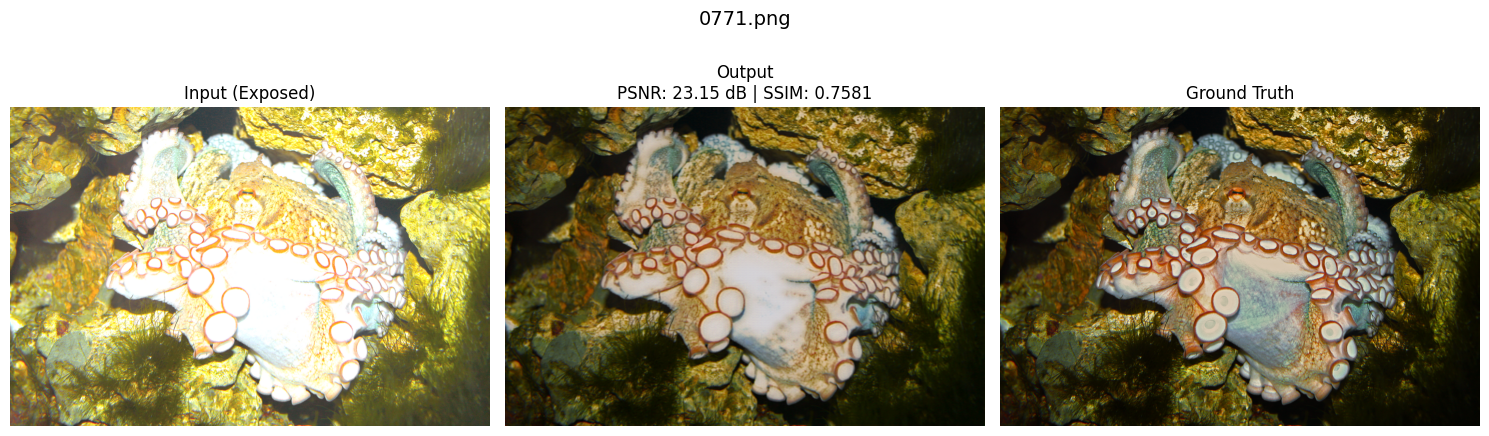

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# CONFIG
INPUT_DIR  = "exposure_dataset/test/input"
RESULT_DIR = "results"
TARGET_DIR = "exposure_dataset/test/target"

filename = sorted(os.listdir(INPUT_DIR))[20]   # choose any index


# Load images
inp_img = Image.open(os.path.join(INPUT_DIR, filename)).convert("RGB")
res_img = Image.open(os.path.join(RESULT_DIR, filename)).convert("RGB")
tgt_img = Image.open(os.path.join(TARGET_DIR, filename)).convert("RGB")

# Resize RESULT → GT shape
if res_img.size != tgt_img.size:
    res_img = res_img.resize(tgt_img.size, Image.BICUBIC)


# Convert to NumPy [0,1]
inp_np = np.asarray(inp_img).astype(np.float32) / 255.0
res_np = np.asarray(res_img).astype(np.float32) / 255.0
tgt_np = np.asarray(tgt_img).astype(np.float32) / 255.0

# --------------------------------
# Metrics (per-image)
# --------------------------------
psnr_val = peak_signal_noise_ratio(tgt_np, res_np, data_range=1.0)

ssim_val = structural_similarity(
    tgt_np,
    res_np,
    data_range=1.0,
    channel_axis=2,
    gaussian_weights=True,
    sigma=1.5,
    use_sample_covariance=False
)

# --------------------------------
# Visualization
# --------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(inp_np)
axes[0].set_title("Input (Exposed)")
axes[0].axis("off")

axes[1].imshow(res_np)
axes[1].set_title(f"Output\nPSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f}")
axes[1].axis("off")

axes[2].imshow(tgt_np)
axes[2].set_title("Ground Truth")
axes[2].axis("off")

plt.suptitle(filename, fontsize=14)
plt.tight_layout()
plt.show()
